# БДЗ 2

In [1]:
import sys
# sys.path.append("src")
import os
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"
import warnings
warnings.filterwarnings('ignore', message='.*Converting mask without torch.bool.*')

In [2]:
import torch
from torch.utils.data import DataLoader
import torchtext
from pathlib import Path
import sacrebleu
from torch import nn
from typing import List, Optional, Dict

from src.dataset import TranslationDataset
from src.inference import translate_file
from src.data_utils import create_token_dataloader, CollateFn, evaluate_model_on_validation
from src.train import train, InverseSqrtScheduler
from src.prepare_spm import train_sentencepiece

from src.models.rnn import Seq2Seq
from src.models.transformer import TransformerMT
from src.models.transformer2 import TransformerMT2
from src.models.transformer_best import TransformerBest

In [3]:
print(f"PyTorch версия: {torch.__version__}")
print(f"torchtext версия: {torchtext.__version__}")
print(f"sacrebleu версия: {sacrebleu.__version__}")

PyTorch версия: 2.10.0
torchtext версия: 0.6.0
sacrebleu версия: 2.6.0


In [4]:
# обучение sentencepiece

DATA_DIR = "data"
FORCE_RETRAIN_SPM = False # принудительное пересоздание модели SentencePiece
VOCAB_SIZE = 32000

SPM_MODEL_PATH = Path(DATA_DIR) / "sentencepiece.model"

if not SPM_MODEL_PATH.exists() or FORCE_RETRAIN_SPM:
    print("SentencePiece model not found. Training...")
    train_sentencepiece(
        data_dir=DATA_DIR,
        vocab_size=VOCAB_SIZE,
        model_prefix="unigram"
    )
else:
    print("SentencePiece model already exists.")

SentencePiece model already exists.


In [5]:
# даталоадеры

train_ds = TranslationDataset(
    "train.de-en.de",
    "train.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

val_ds = TranslationDataset(
    "val.de-en.de",
    "val.de-en.en",
    "sentencepiece.model",
    DATA_DIR
)

DEBUG = False
DEBUG_SAMPLES = 2000

if DEBUG:
    train_ds.src_lines = train_ds.src_lines[:DEBUG_SAMPLES]
    train_ds.tgt_lines = train_ds.tgt_lines[:DEBUG_SAMPLES]
    
    # val_ds.src_lines = val_ds.src_lines[:64]
    # val_ds.tgt_lines = val_ds.tgt_lines[:64]

BATCH_SIZE = 64
PAD = train_ds.PAD
vocab_size = train_ds.vocab_size + 3

# батч по токенам 

train_loader = create_token_dataloader(train_ds, 12000, shuffle=True)
val_loader = create_token_dataloader(val_ds, 12000, shuffle=False)

# батч по текстам

# train_loader = DataLoader(
#     train_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=True,
#     collate_fn=CollateFn(PAD)
# )

# val_loader = DataLoader(
#     val_ds,
#     batch_size=BATCH_SIZE,
#     shuffle=False,
#     collate_fn=CollateFn(PAD)
# )

In [6]:
# модель

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
# device = torch.device("cpu")


# FIRST TRANSFORMER

# model = TransformerMT(
#     vocab_size=vocab_size,
#     emb_size=512,
#     nhead=8,
#     num_encoder_layers=6,
#     num_decoder_layers=6,
#     dim_feedforward=2048,
#     dropout=0.1,
#     pad_idx=train_ds.PAD,
#     max_len=512
# ).to(device)

# SECOND TRANSFORMER

# model = TransformerMT2(
#     vocab_size=vocab_size,
#     d_model=512,
#     nhead=8,
#     num_encoder_layers=6,
#     num_decoder_layers=6,
#     dim_feedforward=2048,
#     dropout=0.1,
#     pad_idx=PAD,
#     max_len=512,
# ).to(device)

# BEST TRANSFORMER

model = TransformerBest(
    vocab_size=vocab_size,
    d_model=512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    pad_idx=PAD
).to(device)


/Users/andrey/study/dl-1/hw/bhw-2/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


In [7]:
# параметры обучения
NUM_EPOCHS = 50


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    betas=(0.9, 0.98),
    eps=1e-9
)

# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=2e-4,
#     betas=(0.9, 0.98),
#     eps=1e-9,
#     weight_decay=1e-5
# )

# scheduler = torch.optim.lr_scheduler.OneCycleLR(
#     optimizer,
#     max_lr=5e-4,
#     epochs=NUM_EPOCHS,
#     steps_per_epoch=len(train_loader),
#     pct_start=0.1,
#     anneal_strategy='cos',
#     div_factor=25,
#     final_div_factor=1000,
# )


scheduler = InverseSqrtScheduler(optimizer, d_model=512, warmup_steps=4000, factor=1.0)

criterion = nn.CrossEntropyLoss(ignore_index=PAD, label_smoothing=0.10)

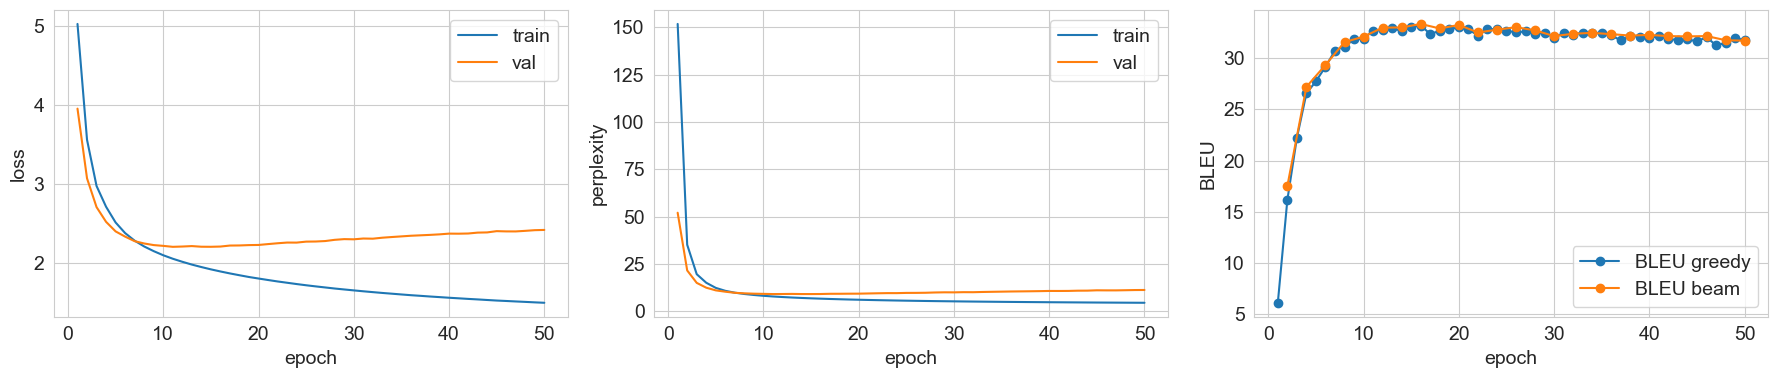

In [8]:
train_losses, val_losses, train_ppls, val_ppls, bleu_greedy, bleu_beam = train(
    model=model,
    optimizer=optimizer,
    scheduler=scheduler,
    criterion=criterion,
    train_loader=train_loader,
    val_loader=val_loader,
    pad_idx=PAD,
    num_epochs=NUM_EPOCHS,
    val_dataset=val_ds,
    max_decoding_len=50,
    greedy_bleu_every=1,
    beam_bleu_every=2,
    bleu_best_model='greedy',
    tmp_val_out="outputs/val_predictions.en",
    device=device,
    inference_batch_size=64,
    no_repeat_ngram_size=3,
    gradient_accumulation_steps=1,
    word_dropout=0.0,
    plot=True
)

In [9]:
# torch.save(model.state_dict(), "checkpoints/cur_model.pt")

In [10]:
# model.load_state_dict(torch.load("checkpoints/cur_model.pt"))
# model.eval()  

In [11]:
checkpoint_bleu = torch.load("checkpoints/best_by_bleu_greedy.pt", map_location=device)
checkpoint_loss = torch.load("checkpoints/best_by_loss.pt", map_location=device)

best_loss_model = TransformerBest(
    vocab_size=vocab_size,
    d_model=512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    pad_idx=PAD
).to(device)

best_bleu_model = TransformerBest(
    vocab_size=vocab_size,
    d_model=512,
    nhead=8,
    num_encoder_layers=6,
    num_decoder_layers=6,
    dim_feedforward=2048,
    dropout=0.1,
    pad_idx=PAD
).to(device)


best_loss_model.load_state_dict(checkpoint_loss["model_state_dict"])
best_bleu_model.load_state_dict(checkpoint_bleu["model_state_dict"])

/Users/andrey/study/dl-1/hw/bhw-2/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:144: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = TransformerEncoder(


<All keys matched successfully>

In [13]:
print(checkpoint_loss["epoch"])
print(checkpoint_bleu["epoch"])

11
16


In [ ]:
results = evaluate_model_on_validation(
    model=best_bleu_model,
    dataset=val_ds,
    device=device,
    batch_size=64,
    beam_size=5,
    no_repeat_ngram_size=3,
    run_greedy=True,
    run_beam=True,
    n_examples=3,
    max_decoding_len=80
)

In [ ]:
results = evaluate_model_on_validation(
    model=best_bleu_model,
    dataset=val_ds,
    device=device,
    batch_size=64,
    beam_size=10,
    no_repeat_ngram_size=0,
    run_greedy=True,
    run_beam=True,
    n_examples = 3,
    max_decoding_len=100,
)

In [14]:
# прогноз для тестового набора

test_lines = open("data/test1.de-en.de", encoding="utf-8").read().splitlines()

OUTPUT_PATH = "outputs/test1.de-en.en"

translate_file(
    model=best_bleu_model,
    dataset=train_ds,
    input_lines=test_lines,
    max_decoding_len=100,
    device=device,
    output_path=OUTPUT_PATH,
    batch_size=64,
    mode="beam",
    beam_size=10,
    no_repeat_ngram_size=0,
)

print(f"Test translations saved to {OUTPUT_PATH}")

Test translations saved to outputs/test1.de-en.en
